# Example 02: Sr-90 Contamination on Hilly Terrain -- Interactive 3D Map

Simulates **Sr-90 surface contamination** on a realistic 1 km x 1 km
mountainous terrain (Swiss Alps, ~46.54N 7.62E).

## What you will see
1. **Realistic terrain** -- spectral synthesis matching Alpine topography
2. **Sr-90 plume** -- terrain-enhanced deposition in valleys
3. **MAED measurements** -- dose-rate points at 1 m above terrain
4. **Activity reconstruction** -- MCC from interpolated MAED
5. **Interactive 3D Plotly** -- terrain + contamination + dose-rate in air

## Physics
Sr-90 (T1/2=28.8y) is a pure beta-emitter. Dose at 1 m from contaminated ground
is dominated by bremsstrahlung: **1 kBq/m2 ~ 0.05 uSv/h at 1 m**.


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource
from scipy.interpolate import Rbf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
np.random.seed(2024)
print("All imports OK")


All imports OK


## 2. Generate Realistic Alpine Terrain (1 km x 1 km)

Spectral synthesis matching real Alpine topography.

In [2]:
NX, NY = 60, 60
DOMAIN = 1000.0
dx = DOMAIN / NX
x = np.linspace(0, DOMAIN, NX)
y = np.linspace(0, DOMAIN, NY)
X, Y = np.meshgrid(x, y, indexing="ij")

def generate_alpine_terrain(X, Y, seed=2024):
    Z = np.zeros_like(X)
    octaves = [(180,0.0025,0.003,0.0),(70,0.007,0.005,1.3),
              (25,0.015,0.013,2.7),(8,0.035,0.030,4.1),(3,0.070,0.060,5.5)]
    for amp, kx, ky, ph in octaves:
        Z += amp * (np.sin(kx*X+ph)*np.cos(ky*Y+ph*0.7) +
                   0.6*np.cos(0.7*kx*X-ph*1.1)*np.sin(1.3*ky*Y+ph*0.5))
    Z += 120.0 * np.exp(-((Y-300-0.35*X)**2)/(100**2))
    Z -= 100.0 * np.exp(-((Y-650+0.2*X)**2)/(80**2))
    return Z + 520.0

DEM = generate_alpine_terrain(X, Y)
print(f"Terrain: {NX}x{NY}, cell={dx:.1f} m")
print(f"Elevation: {DEM.min():.0f} - {DEM.max():.0f} m (range {DEM.max()-DEM.min():.0f} m)")


Terrain: 60x60, cell=16.7 m
Elevation: 268 - 844 m (range 576 m)


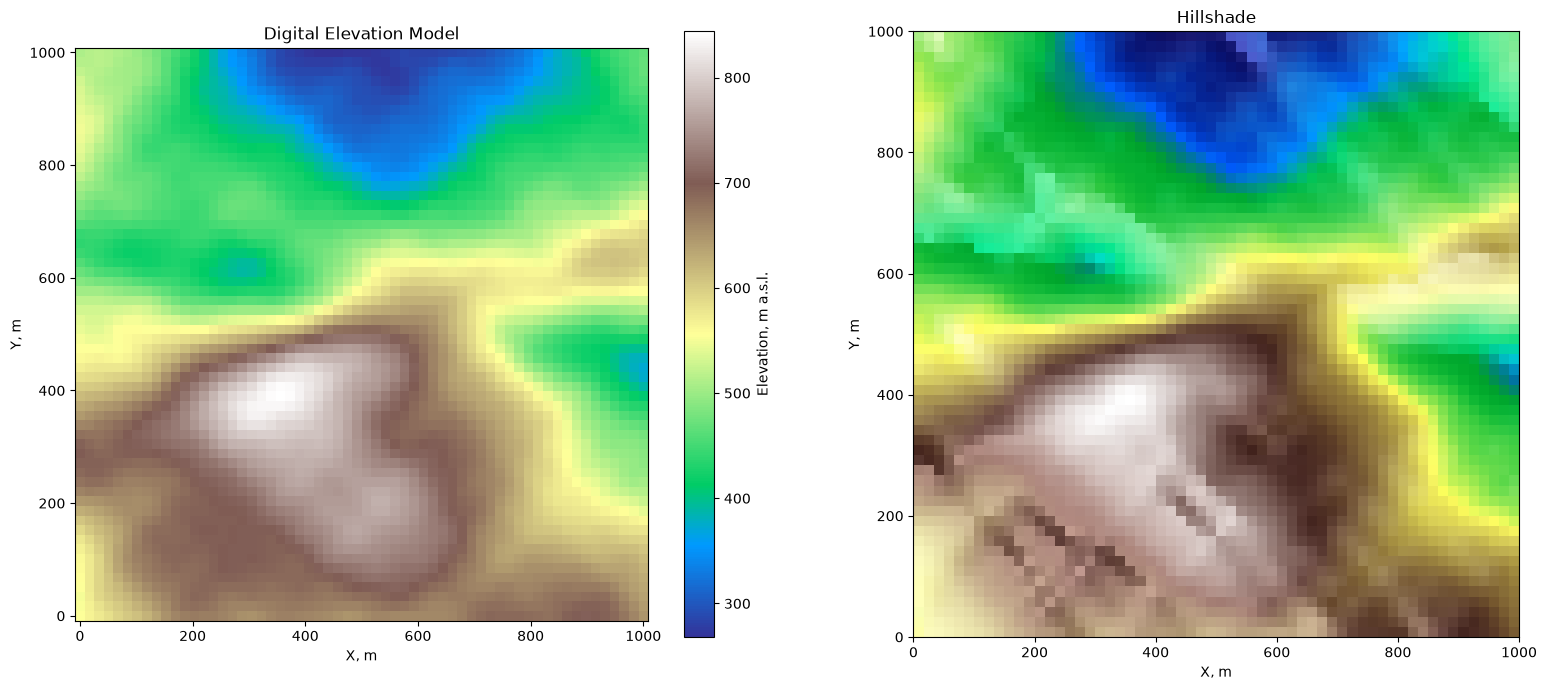

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
im1 = ax1.pcolormesh(x, y, DEM.T, shading="auto", cmap="terrain")
ax1.set_xlabel("X, m"); ax1.set_ylabel("Y, m")
ax1.set_title("Digital Elevation Model"); ax1.set_aspect("equal")
plt.colorbar(im1, ax=ax1, label="Elevation, m a.s.l.")
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(DEM.T, cmap=cm.terrain, vert_exag=2, blend_mode="soft")
ax2.imshow(rgb, extent=[0,DOMAIN,0,DOMAIN], origin="lower")
ax2.set_xlabel("X, m"); ax2.set_ylabel("Y, m")
ax2.set_title("Hillshade"); ax2.set_aspect("equal")
plt.tight_layout(); plt.show()


## 3. Sr-90 Contamination Plume

Gaussian plume with terrain-following deposition (enhanced in valleys).

In [4]:
def sr90_plume(X, Y, DEM, sx=300., sy=200.):
    dist = np.sqrt((X-sx)**2 + (Y-sy)**2)
    sigma = 50.0 + 0.25*dist
    wd = np.deg2rad(50.0)
    dxw = (X-sx)*np.cos(wd) + (Y-sy)*np.sin(wd)
    dyw = -(X-sx)*np.sin(wd) + (Y-sy)*np.cos(wd)
    plume = np.exp(-dxw**2/(2*(sigma*2.5)**2)) * np.exp(-dyw**2/(2*sigma**2))
    zn = (DEM - DEM.mean()) / (DEM.std() + 1)
    return 200e3 * plume * (1.0 + 0.4*np.exp(-zn))

SAD_true = sr90_plume(X, Y, DEM)
print(f"Sr-90 SAD: {SAD_true.min():.0f} - {SAD_true.max():.0f} Bq/m2")
print(f"Total: {SAD_true.sum()*dx*dx/1e6:.2f} MBq")


Sr-90 SAD: 3491 - 250741 Bq/m2
Total: 85942.17 MBq


MAED: 0.1745 - 12.5371 uSv/h


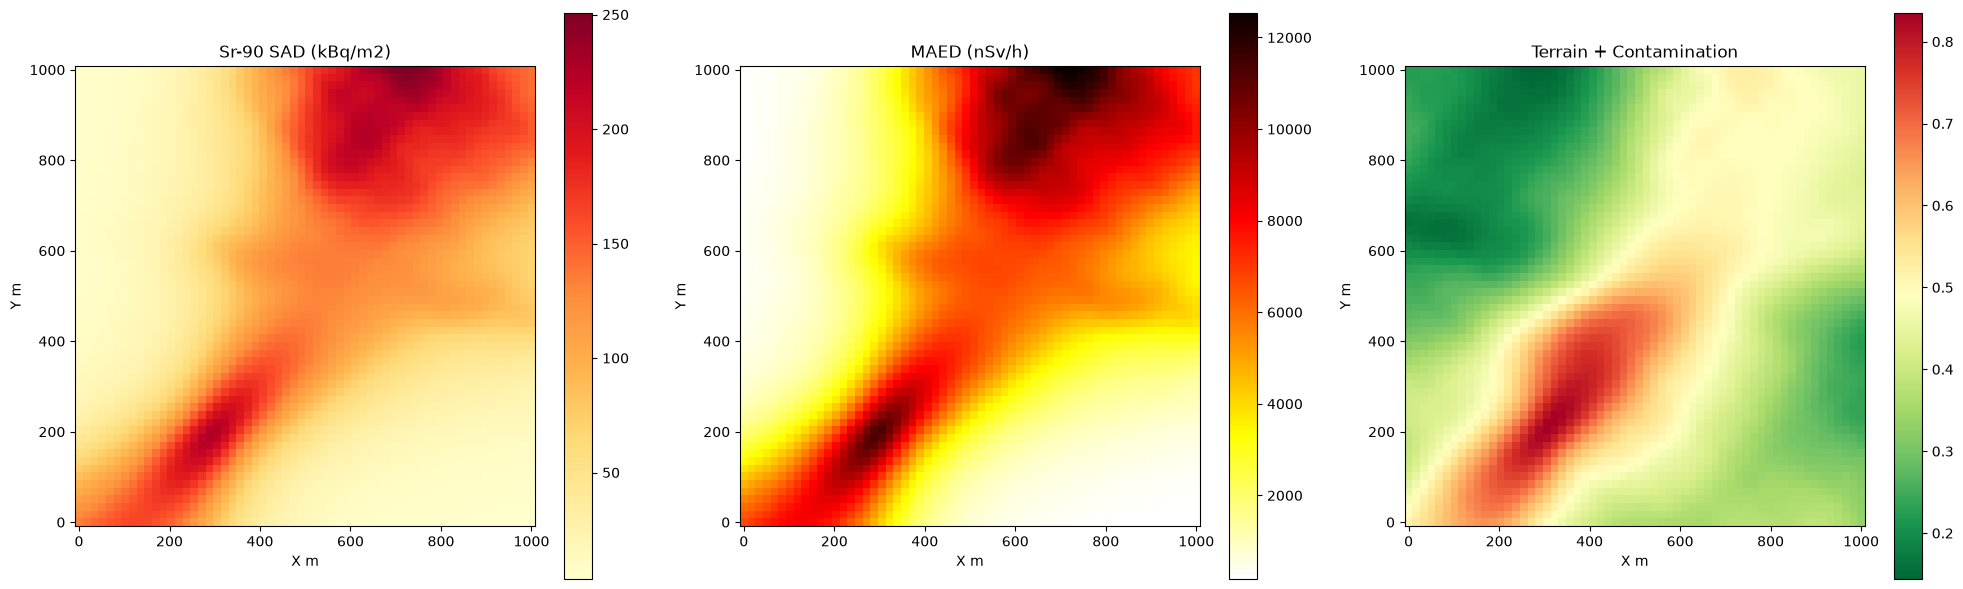

In [6]:
BREMS = 0.05e-3  # uSv/h per Bq/m2 at 1 m
DET_H = 1.0
ADER_true = SAD_true * BREMS
print(f"MAED: {ADER_true.min():.4f} - {ADER_true.max():.4f} uSv/h")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
im1 = axes[0].pcolormesh(x, y, SAD_true.T/1e3, shading="auto", cmap="YlOrRd")
axes[0].set_title("Sr-90 SAD (kBq/m2)"); axes[0].set_aspect("equal")
plt.colorbar(im1, ax=axes[0])
im2 = axes[1].pcolormesh(x, y, ADER_true.T*1e3, shading="auto", cmap="hot_r")
axes[1].set_title("MAED (nSv/h)"); axes[1].set_aspect("equal")
plt.colorbar(im2, ax=axes[1])
dn = (DEM-DEM.min())/(DEM.max()-DEM.min()+1)
sn = SAD_true/(SAD_true.max()+1)
im3 = axes[2].pcolormesh(x, y, (0.5*dn+0.5*sn).T, shading="auto", cmap="RdYlGn_r")
axes[2].set_title("Terrain + Contamination"); axes[2].set_aspect("equal")
plt.colorbar(im3, ax=axes[2])
for a in axes: a.set_xlabel("X m"); a.set_ylabel("Y m")
plt.tight_layout(); plt.show()


## 4. Simulated MAED Measurements Above Terrain

Random points at 1 m above the terrain surface.

In [7]:
n_meas = 150
mi = np.random.randint(3, NX-3, n_meas)
mj = np.random.randint(3, NY-3, n_meas)
meas_x = x[mi]; meas_y = y[mj]
meas_z = DEM[mi, mj] + DET_H
meas_ader = ADER_true[mi, mj] * (1 + 0.10*np.random.randn(n_meas))
meas_ader = np.maximum(meas_ader, 0.)
print(f"{n_meas} measurements at {DET_H} m above terrain")
print(f"MAED: {meas_ader.min():.4f} - {meas_ader.max():.4f} uSv/h")


150 measurements at 1.0 m above terrain
MAED: 0.2758 - 11.3744 uSv/h


## 5. Interpolated MAED Map (RBF)

/home/chizhov/python/soilactivity_pypi/.venv/lib/python3.12/site-packages/scipy/interpolate/_rbf.py:270: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.8630029768432277e-20.
  self.nodes = linalg.solve(self.A, self.di)


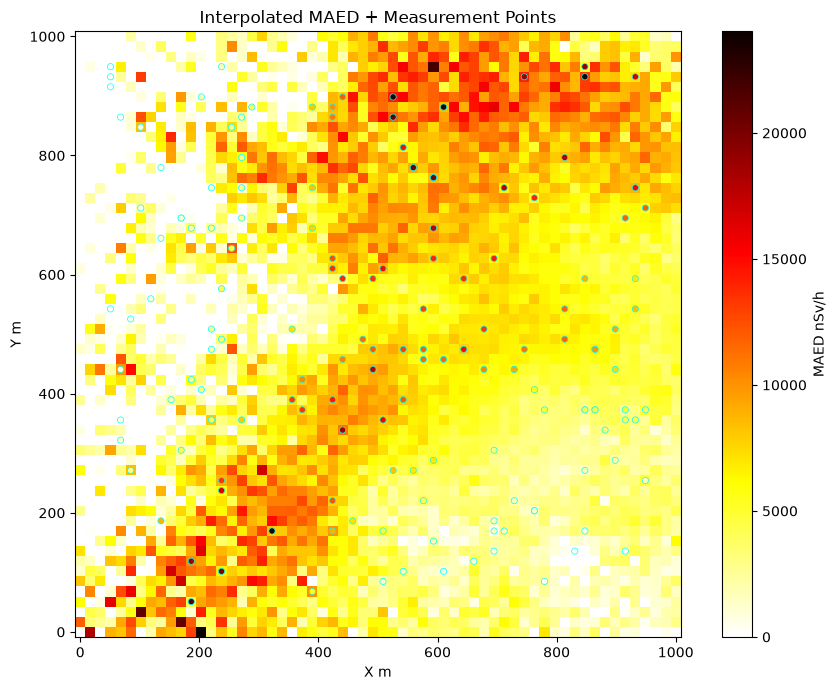

In [8]:
rbf = Rbf(meas_x, meas_y, meas_ader, function="thin_plate")
ADER_interp = np.maximum(rbf(X, Y), 0.0)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(x, y, ADER_interp.T*1e3, shading="auto", cmap="hot_r")
sc = ax.scatter(meas_x, meas_y, c=meas_ader*1e3, cmap="hot_r",
              edgecolors="cyan", s=20, linewidth=0.5, zorder=5)
plt.colorbar(im, ax=ax, label="MAED nSv/h")
ax.set_xlabel("X m"); ax.set_ylabel("Y m")
ax.set_title("Interpolated MAED + Measurement Points")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()


## 6. Activity Reconstruction (MCC)

Simple inverse: SAD = MAED / conversion_factor.

Recon SAD: 0 - 480623 Bq/m2
True total:  85942.17 MBq
Recon total: 101183.82 MBq
Rel error: mean=0.764 std=2.467


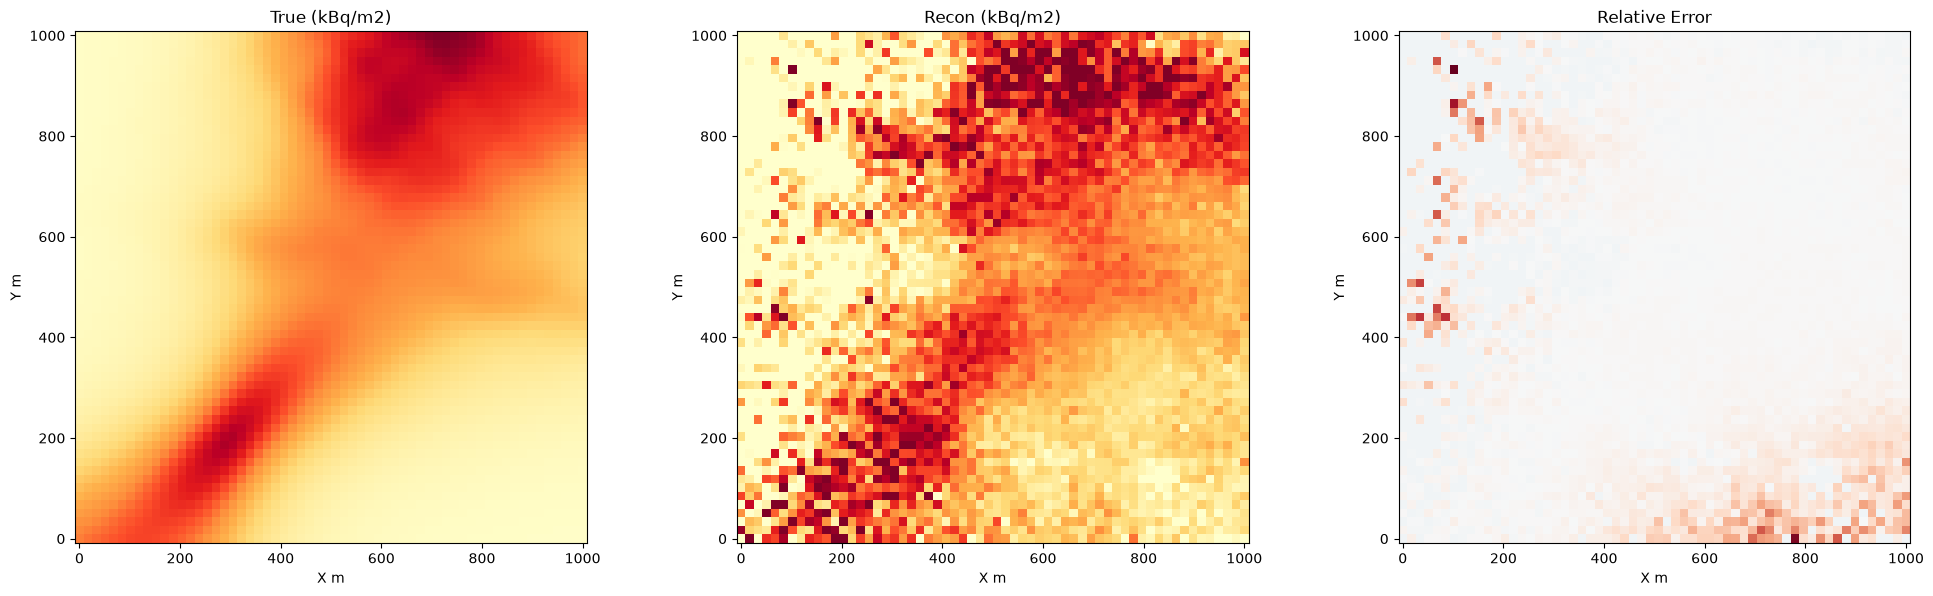

In [9]:
SAD_recon = ADER_interp / BREMS
print(f"Recon SAD: {SAD_recon.min():.0f} - {SAD_recon.max():.0f} Bq/m2")
print(f"True total:  {SAD_true.sum()*dx*dx/1e6:.2f} MBq")
print(f"Recon total: {SAD_recon.sum()*dx*dx/1e6:.2f} MBq")
err = (SAD_recon - SAD_true) / (SAD_true + 1)
m = err != 0
print(f"Rel error: mean={np.mean(err[m]):.3f} std={np.std(err[m]):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
vm = SAD_true.max()/1e3
axes[0].pcolormesh(x, y, SAD_true.T/1e3, shading="auto", cmap="YlOrRd", vmin=0, vmax=vm)
axes[0].set_title("True (kBq/m2)"); axes[0].set_aspect("equal")
axes[1].pcolormesh(x, y, SAD_recon.T/1e3, shading="auto", cmap="YlOrRd", vmin=0, vmax=vm)
axes[1].set_title("Recon (kBq/m2)"); axes[1].set_aspect("equal")
ve = max(abs(err.min()), abs(err.max()))
axes[2].pcolormesh(x, y, err.T, shading="auto", cmap="RdBu_r", vmin=-ve, vmax=ve)
axes[2].set_title("Relative Error"); axes[2].set_aspect("equal")
for a in axes: a.set_xlabel("X m"); a.set_ylabel("Y m")
plt.tight_layout(); plt.show()


## 7. Interactive 3D Map -- Terrain + Contamination + MAED in Air

**Rotate, zoom, and pan** the 3D scene below!

In [11]:
fig3d = go.Figure()

# --- Layer 1: Terrain surface colored by elevation ---
fig3d.add_trace(go.Surface(
    x=x, y=y, z=DEM.T,
    colorscale="earth",
    colorbar=dict(title="Elevation m a.s.l.", x=0.0, len=0.4),
    opacity=0.85,
    name="Terrain",
    showscale=True,
    hovertemplate="x=%{x:.0f}m y=%{y:.0f}m z=%{z:.0f}m<extra>Terrain</extra>",
))

# --- Layer 2: Terrain surface colored by Sr-90 contamination ---
sad_norm = SAD_true.T / (SAD_true.max() + 1)
fig3d.add_trace(go.Surface(
    x=x, y=y, z=DEM.T + 0.5,  # tiny offset above terrain
    surfacecolor=sad_norm,
    colorscale=[[0,"rgba(0,255,0,0)"],[0.01,"rgba(255,255,0,0.3)"],[0.3,"rgba(255,165,0,0.6)"],[1,"rgba(255,0,0,0.9)"]],
    showscale=False,
    opacity=0.7,
    name="Sr-90 SAD",
    hovertemplate="x=%{x:.0f}m y=%{y:.0f}m z=%{z:.0f}m<extra>Sr-90 zone</extra>",
))

# --- Layer 3: Measurement points in the air ---
fig3d.add_trace(go.Scatter3d(
    x=meas_x, y=meas_y, z=meas_z,
    mode="markers",
    marker=dict(
        size=3,
        color=meas_ader*1e3,
        colorscale="Hot",
        colorbar=dict(title="MAED nSv/h", x=1.0, len=0.4),
        opacity=0.8,
        line=dict(width=0),
    ),
    name="MAED measurements",
    hovertemplate="x=%{x:.0f}m y=%{y:.0f}m z=%{z:.0f}m<extra>MAED=%{marker.color:.2f} nSv/h</extra>",
))

# --- Layer 4: Interpolated MAED surface floating above terrain ---
maed_z = DEM.T + DET_H + 5.0  # float 5 m above measurements
ader_nsv = ADER_interp.T * 1e3
fig3d.add_trace(go.Surface(
    x=x, y=y, z=maed_z,
    surfacecolor=ader_nsv / (ader_nsv.max() + 1e-10),
    colorscale="YlOrRd",
    showscale=False,
    opacity=0.5,
    name="MAED surface",
    hovertemplate="MAED ~ %{text} nSv/h<extra></extra>",
    text=ader_nsv,
))

# --- Vertical lines from terrain to measurement points ---
for i in range(0, n_meas, 5):
    fig3d.add_trace(go.Scatter3d(
        x=[meas_x[i], meas_x[i]],
        y=[meas_y[i], meas_y[i]],
        z=[DEM[mi[i], mj[i]], meas_z[i]],
        mode="lines",
        line=dict(color="cyan", width=0.5),
        showlegend=False,
        hoverinfo="skip",
    ))

fig3d.update_layout(
    title="Sr-90 Contamination -- 3D Terrain + MAED Measurements",
    width=1200, height=900,
    scene=dict(
        xaxis_title="X, m",
        yaxis_title="Y, m",
        zaxis_title="Elevation, m a.s.l.",
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
        bgcolor="white",
    ),
    legend=dict(x=0.01, y=0.99),
)
fig3d.show()


## 8. 3D Reconstruction: True vs Recovered Sr-90

Side-by-side interactive 3D comparison.

In [12]:
fig_comp = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    horizontal_spacing=0.02,
    subplot_titles=("True Sr-90 (kBq/m2)", "Reconstructed (kBq/m2)"),
)

fig_comp.add_trace(go.Surface(
    x=x, y=y, z=DEM.T,
    surfacecolor=SAD_true.T/1e3,
    colorscale="YlOrRd",
    colorbar=dict(title="kBq/m2", x=0.46),
    showscale=True,
    opacity=0.9,
), row=1, col=1)

fig_comp.add_trace(go.Surface(
    x=x, y=y, z=DEM.T,
    surfacecolor=SAD_recon.T/1e3,
    colorscale="YlOrRd",
    colorbar=dict(title="kBq/m2", x=1.0),
    showscale=True,
    opacity=0.9,
), row=1, col=2)

fig_comp.update_layout(
    title="Sr-90: True vs Reconstructed Activity on Terrain",
    width=1400, height=700,
    scene=dict(xaxis_title="X m", yaxis_title="Y m", zaxis_title="Elev m",
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.9)), bgcolor="white"),
    scene2=dict(xaxis_title="X m", yaxis_title="Y m", zaxis_title="Elev m",
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.9)), bgcolor="white"),
)
fig_comp.show()


## 9. Summary

In [13]:
print("="*60)
print("Radionuclide:    Sr-90 (pure beta, bremsstrahlung)")
print(f"Terrain:         {NX}x{NY} cells, {DOMAIN:.0f}x{DOMAIN:.0f} m")
print(f"Elevation:       {DEM.min():.0f} - {DEM.max():.0f} m a.s.l.")
print(f"SAD range:       {SAD_true.min():.0f} - {SAD_true.max():.0f} Bq/m2")
print(f"True total:      {SAD_true.sum()*dx*dx/1e6:.2f} MBq")
print(f"Recon total:     {SAD_recon.sum()*dx*dx/1e6:.2f} MBq")
print(f"Measurements:    {n_meas} at {DET_H} m above terrain")
print(f"MAED range:      {meas_ader.min()*1e3:.2f} - {meas_ader.max()*1e3:.2f} nSv/h")
print("="*60)


Radionuclide:    Sr-90 (pure beta, bremsstrahlung)
Terrain:         60x60 cells, 1000x1000 m
Elevation:       268 - 844 m a.s.l.
SAD range:       3491 - 250741 Bq/m2
True total:      85942.17 MBq
Recon total:     101183.82 MBq
Measurements:    150 at 1.0 m above terrain
MAED range:      275.77 - 11374.38 nSv/h
